# Unidad 4 — Selección de arquitectura ganadora — Grupo 3

**Curso:** Computación en la Nube para IA · **Fecha:** 2026-09-18

**Integrantes:** Ricardo Chamorro Martinez, Oscar Stiven Muñoz Ramirez, Juan Camilo Muñoz Barco, Sebastian Erazo Ochoa

**Objetivo:** convertir el trabajo de auditoría de género de Unidad 3 en un proceso real de selección de modelo. Competimos **3 arquitecturas distintas** (XGBoost, LightGBM, Regresión Logística), cada una con su **propia búsqueda de hiperparámetros** (Optuna), comparamos **base vs. mitigado** (reweighting sobre `gender`) con un scorecard de AUC, Recall, DPD, EOD y costo de negocio en USD, seleccionamos con un leaderboard 360 y registramos las mejores en Model Registry.


### Nota de metodología

- Las **features son las 13 que Grupo 3 seleccionó y justificó en Unidad 3** (sección 10 del notebook de auditoría de género): `gender, SeniorCitizen, Partner, Dependents, tenure, Contract, PaymentMethod, MonthlyCharges, InternetService, OnlineSecurity, TechSupport, PaperlessBilling`. No se agregan ni se quitan features sin justificación adicional.
- La **variable protegida es `gender`** (columna `gender_Male` tras el one-hot).
- **3 arquitecturas reales** (familias de modelo distintas), no configuraciones del mismo modelo: XGBoost, LightGBM, Logistic Regression. Cada una con su propia búsqueda Optuna (5-fold CV, multi-objetivo AUC↑ / std↓).
- Por cada arquitectura: versión **base** (sin `sample_weight`) vs. **mitigada** (con `sample_weight` sobre la intersección `gender_Male × Churn`) — así se calcula el costo de equidad y el resto del scorecard.
- Costos de negocio: `FN=$150` (costo de reconexión), `FP=1 mes de MonthlyCharges` (oferta de retención regalada innecesariamente).


---
## Setup

#superimportante

```
gcloud workbench instances create u4-g03 --project=computacionnube20261 --location=us-central1-a --machine-type=e2-standard-2 --metadata=idle-timeout-seconds=2700
```

en Cloud Shell, para crear la instancia correctamente (revisar nomenclatura oficial del grupo antes de correr).

In [39]:
# Instalar librerías necesarias
!pip install google-cloud-bigquery google-cloud-aiplatform google-cloud-storage optuna xgboost lightgbm fairlearn --quiet

print("Librerías instaladas correctamente")


Librerías instaladas correctamente


In [40]:
# ========================================
# CONFIGURACIÓN
# ========================================
from google.cloud import bigquery
from google.cloud import aiplatform
import pandas as pd
import numpy as np

GROUP_NUM = "g03"
FECHA_CLASE = "20260918"   # hoy

PROJECT_ID = "computacionnube20263"  # Proyecto confirmado del curso
REGION = "us-central1"
SOURCE_TABLE = f"{PROJECT_ID}.u3_master.telco_churn_raw"

# ---- Nomenclatura oficial: u4_gNN_<tipo>_YYYYMMDD ----
BUCKET_NAME = f"{PROJECT_ID}-u4-{GROUP_NUM}-mdl-{FECHA_CLASE}"
BQ_RESOURCE_NAME = f"u4_{GROUP_NUM}_data_{FECHA_CLASE}"
EXPERIMENT_NAME = f"u4-{GROUP_NUM}-expchurn-{FECHA_CLASE}"   # guion, no guion bajo (lios con Experiments)

TARGET = "Churn"
PROTECTED_VAR_RAW = "gender"        # variable protegida cruda (BigQuery)
PROTECTED_VAR_ENC = "gender_Male"   # columna post one-hot que usa fairlearn
EOD_MAX = 0.2

COSTO_DESCONEXION_USD = 150
MESES_OFERTA_RETENCION = 1

bq_client = bigquery.Client(project=PROJECT_ID)
aiplatform.init(project=PROJECT_ID, location=REGION, experiment=EXPERIMENT_NAME)

print(f"Grupo: {GROUP_NUM} | Fecha: {FECHA_CLASE} | Experimento: {EXPERIMENT_NAME}")
print(f"Bucket: {BUCKET_NAME}")
print("Clientes inicializados (BigQuery + Vertex AI)")


Grupo: g03 | Fecha: 20260918 | Experimento: u4-g03-expchurn-20260918
Bucket: computacionnube20263-u4-g03-mdl-20260918
Clientes inicializados (BigQuery + Vertex AI)


---
## SECCIÓN 1: Carga de datos — las 13 columnas de Tarea 1 (g03)

Mismas columnas que `u3-g03-nb-20260901.ipynb`, sección 10 (modelo ampliado + auditoría de género). `Churn` llega de BigQuery como booleano nativo.

In [41]:
# ========================================
# CARGA DE DATOS -- 13 columnas justificadas en Tarea 1
# ========================================
columnas_hoy = [
    'customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
    'Contract', 'PaymentMethod', 'MonthlyCharges',
    'InternetService', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling',
    'Churn'
]

query = f"SELECT {', '.join(columnas_hoy)} FROM `{SOURCE_TABLE}`"
df = bq_client.query(query).to_dataframe()

df['Churn'] = df['Churn'].astype(int)
df['SeniorCitizen'] = df['SeniorCitizen'].astype(int)

print(f"Filas: {len(df)} | Columnas: {len(df.columns)}")
print(f"\nDistribución de Churn: {df['Churn'].value_counts(normalize=True).round(3).to_dict()}")
print(f"Distribución de gender: {df['gender'].value_counts(normalize=True).round(3).to_dict()}")
df.head(3)


Filas: 7043 | Columnas: 14

Distribución de Churn: {0: 0.735, 1: 0.265}
Distribución de gender: {'Male': 0.505, 'Female': 0.495}


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,Contract,PaymentMethod,MonthlyCharges,InternetService,OnlineSecurity,TechSupport,PaperlessBilling,Churn
0,9426-SXNHE,Female,0,False,False,2,Month-to-month,Bank transfer (automatic),18.75,No,No internet service,No internet service,False,0
1,3806-YAZOV,Female,0,False,False,3,Month-to-month,Mailed check,18.80,No,No internet service,No internet service,False,0
2,3387-PLKUI,Female,0,True,True,13,Month-to-month,Mailed check,18.80,No,No internet service,No internet service,False,0


---
## SECCIÓN 2: Feature engineering + preparación

One-hot de las categóricas (`gender`, `Partner`, `Dependents`, `Contract`, `PaymentMethod`, `InternetService`, `OnlineSecurity`, `TechSupport`, `PaperlessBilling`) — mismo criterio que `u3-g03-nb-20260901.ipynb`. `SeniorCitizen` se queda 0/1. Sin escalado para los modelos de árboles (XGBoost/LightGBM son invariantes); la Regresión Logística escala internamente vía `Pipeline`.

In [42]:
# ========================================
# FEATURE ENGINEERING
# ========================================
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
import re

y = df['Churn']
customer_ids = df['customerID']
X = df.drop(columns=['Churn', 'customerID']).copy()

cat_cols = ['gender', 'Partner', 'Dependents', 'Contract', 'PaymentMethod',
            'InternetService', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling']

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X_encoded = X_encoded.astype(float)

def limpiar_nombre_columna(col):
    return re.sub(r'[^0-9a-zA-Z_]', '_', col)

X_encoded.columns = [limpiar_nombre_columna(c) for c in X_encoded.columns]
PROTECTED_VAR_ENC = limpiar_nombre_columna(PROTECTED_VAR_ENC)

print(f"Columnas después del encoding: {X_encoded.shape[1]}")
print(list(X_encoded.columns))
assert PROTECTED_VAR_ENC in X_encoded.columns, f"No se encontró {PROTECTED_VAR_ENC} -- revisar encoding"

# Split -- mismo criterio que Unidad 3 (random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Guardamos gender y MonthlyCharges "crudos" del test set (fairness + costo de negocio)
gender_test = X_test[PROTECTED_VAR_ENC].reset_index(drop=True)
monthly_test = X_test['MonthlyCharges'].reset_index(drop=True)
customer_ids_train = customer_ids.loc[X_train.index].reset_index(drop=True)
customer_ids_test = customer_ids.loc[X_test.index].reset_index(drop=True)

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")


Columnas después del encoding: 18
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'gender_Male', 'Partner_True', 'Dependents_True', 'Contract_One_year', 'Contract_Two_year', 'PaymentMethod_Credit_card__automatic_', 'PaymentMethod_Electronic_check', 'PaymentMethod_Mailed_check', 'InternetService_Fiber_optic', 'InternetService_No', 'OnlineSecurity_No_internet_service', 'OnlineSecurity_Yes', 'TechSupport_No_internet_service', 'TechSupport_Yes', 'PaperlessBilling_True']

Train: (5634, 18) | Test: (1409, 18)


---
## SECCIÓN 3: Mitigación (reweighting sobre género)

`sample_weight` calculado por la intersección `gender_Male × Churn` -- **no** `SeniorCitizen`, que es el punto explícito del enunciado de esta tarea.

In [43]:
# ========================================
# SAMPLE WEIGHTS PARA REWEIGHTING (sobre el train set) -- gender x Churn
# ========================================
grupo_interseccion_train = X_train[PROTECTED_VAR_ENC].astype(str) + "_" + y_train.astype(str)
sample_weights_train = compute_sample_weight(class_weight='balanced', y=grupo_interseccion_train)

print("Pesos calculados (primeros 10):")
print(sample_weights_train[:10])


Pesos calculados (primeros 10):
[0.67651297 0.67651297 0.67651297 0.67651297 0.67651297 0.68473505
 0.68473505 0.68473505 0.68473505 0.67651297]


---
## SECCIÓN 4: Competencia entre 3 arquitecturas reales

**Reglas de la competencia (idénticas para las 3, para que sea justa):**
- Mismo split, mismo preprocesamiento
- Cada arquitectura corre su **propia búsqueda Optuna** (n_trials=20, 5-fold CV, optimiza AUC-ROC media y minimiza std)
- La búsqueda NO usa `sample_weight` (busca el mejor perfil de hiperparámetros "genérico" para la arquitectura); el `sample_weight` se aplica después, en el entrenamiento base vs. mitigado (Sección 5) -- así se separa "¿qué arquitectura es mejor?" de "¿cuánto cuesta mitigar?".

In [44]:
# ========================================
# Infraestructura común: CV manual + selección de mejor trial
# ========================================
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

optuna.logging.set_verbosity(optuna.logging.WARNING)
CV_FOLDS = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_auc_manual(model_factory, X, y):
    """CV manual de 5 folds, sin sample_weight -- perfil generico de la arquitectura."""
    aucs = []
    for train_idx, val_idx in CV_FOLDS.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        modelo = model_factory()
        modelo.fit(X_tr, y_tr)
        aucs.append(roc_auc_score(y_val, modelo.predict_proba(X_val)[:, 1]))
    return float(np.mean(aucs)), float(np.std(aucs))

def elegir_modelo(study):
    """Selecciona el trial mas cercano al punto ideal (AUC=1, std=0) entre los pareto-optimos."""
    trials = study.best_trials
    aucs = np.array([t.values[0] for t in trials])
    stds = np.array([t.values[1] for t in trials])
    auc_norm = (aucs - aucs.min()) / (aucs.max() - aucs.min() + 1e-9)
    std_norm = (stds - stds.min()) / (stds.max() - stds.min() + 1e-9)
    distancias = np.sqrt((1 - auc_norm) ** 2 + std_norm ** 2)
    return trials[int(np.argmin(distancias))]

N_TRIALS = 20
print(f"CV: {CV_FOLDS.get_n_splits()} folds | n_trials por arquitectura: {N_TRIALS}")


CV: 5 folds | n_trials por arquitectura: 20


### 4.1 Arquitectura XGBoost

In [45]:
from xgboost import XGBClassifier

def objective_xgb(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.5, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 50, 400),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
    }
    factory = lambda: XGBClassifier(**params, eval_metric="auc", random_state=42, verbosity=0)
    return cv_auc_manual(factory, X_train, y_train)

print("Optimizando XGBoost...")
study_xgb = optuna.create_study(directions=["maximize", "minimize"], study_name="xgb_churn_g03")
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)
trial_xgb = elegir_modelo(study_xgb)
print(f"XGBoost elegido: AUC={trial_xgb.values[0]:.4f} std={trial_xgb.values[1]:.4f}")
print(f"  params: {trial_xgb.params}")


Optimizando XGBoost...


  0%|          | 0/20 [00:00<?, ?it/s]

XGBoost elegido: AUC=0.8492 std=0.0102
  params: {'max_depth': 3, 'learning_rate': 0.05631829961905124, 'n_estimators': 114, 'subsample': 0.8804261093452933, 'colsample_bytree': 0.6854590300234178}


### 4.2 Arquitectura LightGBM

In [46]:
from lightgbm import LGBMClassifier

def objective_lgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 400),
        "num_leaves": trial.suggest_int("num_leaves", 15, 63),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.5, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
    }
    factory = lambda: LGBMClassifier(**params, random_state=42, verbose=-1)
    return cv_auc_manual(factory, X_train, y_train)

print("Optimizando LightGBM...")
study_lgb = optuna.create_study(directions=["maximize", "minimize"], study_name="lgb_churn_g03")
study_lgb.optimize(objective_lgb, n_trials=N_TRIALS, show_progress_bar=True)
trial_lgb = elegir_modelo(study_lgb)
print(f"LightGBM elegido: AUC={trial_lgb.values[0]:.4f} std={trial_lgb.values[1]:.4f}")
print(f"  params: {trial_lgb.params}")


Optimizando LightGBM...


  0%|          | 0/20 [00:00<?, ?it/s]

LightGBM elegido: AUC=0.8412 std=0.0102
  params: {'n_estimators': 153, 'num_leaves': 25, 'max_depth': 9, 'learning_rate': 0.04646367760809373, 'subsample': 0.6121588429260137, 'colsample_bytree': 0.8064279814258146}


### 4.3 Arquitectura Logistic Regression (baseline lineal)

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def objective_lr(trial):
    params = {
        "C": trial.suggest_float("C", 1e-3, 100.0, log=True),
        "solver": trial.suggest_categorical("solver", ["lbfgs", "liblinear"]),
    }
    def factory():
        return Pipeline([
            ("sc", StandardScaler()),
            ("clf", LogisticRegression(**params, penalty="l2", max_iter=1000, random_state=42)),
        ])
    return cv_auc_manual(factory, X_train, y_train)

print("Optimizando Logistic Regression...")
study_lr = optuna.create_study(directions=["maximize", "minimize"], study_name="lr_churn_g03")
study_lr.optimize(objective_lr, n_trials=N_TRIALS, show_progress_bar=True)
trial_lr = elegir_modelo(study_lr)
print(f"LogReg elegido: AUC={trial_lr.values[0]:.4f} std={trial_lr.values[1]:.4f}")
print(f"  params: {trial_lr.params}")


Optimizando Logistic Regression...


  0%|          | 0/20 [00:00<?, ?it/s]

/opt/micromamba/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/micromamba/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/micromamba/lib/python3.12/site-packages/sklearn/lin

LogReg elegido: AUC=0.8415 std=0.0087
  params: {'C': 0.003123378175533915, 'solver': 'lbfgs'}


---
## SECCIÓN 5: Base vs. mitigado -- scorecard de equidad y costo

Para cada arquitectura, entrenamos **base** (sin `sample_weight`) y **mitigada** (con `sample_weight` sobre género), con los hiperparámetros ya encontrados. Calculamos:

- **AUC, Precision, Recall**
- **DPD, EOD** sobre `gender` (equidad)
- **Costo de equidad** = `(EOD_base - EOD_mitigado) / (AUC_base - AUC_mitigado)`
- **Costo de negocio (USD)** = `FN × $150 + Σ(FP → MonthlyCharges × 1 mes)` (sobre la versión mitigada)
- **Score final** = `AUC` si `EOD ≤ 0.2`, si no, descalificado (`-1`)

In [48]:
# ========================================
# Entrenar y evaluar las 3 arquitecturas x (base, mitigado) = 6 modelos
# ========================================
from sklearn.metrics import roc_auc_score, precision_score, recall_score, confusion_matrix
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

def entrenar_y_evaluar(model_factory, sample_weight=None):
    modelo = model_factory()
    fit_kwargs = {}
    if sample_weight is not None:
      if isinstance(modelo, Pipeline):
          fit_kwargs["clf__sample_weight"] = sample_weight
      else:
          fit_kwargs["sample_weight"] = sample_weight
    modelo.fit(X_train, y_train, **fit_kwargs)

    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    return {
        "modelo": modelo,
        "auc": roc_auc_score(y_test, y_proba),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "dpd": demographic_parity_difference(y_test, y_pred, sensitive_features=gender_test),
        "eod": equalized_odds_difference(y_test, y_pred, sensitive_features=gender_test),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "y_pred": y_pred,
    }

arquitecturas = {
    "XGBoost": lambda: XGBClassifier(**trial_xgb.params, eval_metric="auc", random_state=42, verbosity=0),
    "LightGBM": lambda: LGBMClassifier(**trial_lgb.params, random_state=42, verbose=-1),
    "LogReg": lambda: Pipeline([
        ("sc", StandardScaler()),
        ("clf", LogisticRegression(**trial_lr.params, penalty="l2", max_iter=1000, random_state=42)),
    ]),
}

resultados = {}
for nombre, factory in arquitecturas.items():
    print(f"Entrenando {nombre} (base + mitigado)...")
    resultados[f"{nombre}_base"] = entrenar_y_evaluar(factory, sample_weight=None)
    resultados[f"{nombre}_mitigado"] = entrenar_y_evaluar(factory, sample_weight=sample_weights_train)

print("Las 6 configuraciones (3 arquitecturas x base/mitigado) entrenadas y evaluadas")


Entrenando XGBoost (base + mitigado)...
Entrenando LightGBM (base + mitigado)...
Entrenando LogReg (base + mitigado)...


/opt/micromamba/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/micromamba/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Las 6 configuraciones (3 arquitecturas x base/mitigado) entrenadas y evaluadas


In [49]:
# ========================================
# MÉTRICAS PROPIAS: costo de equidad, costo de negocio, score final
# ========================================
def costo_equidad_ratio(res_base, res_mit):
    delta_auc = res_base["auc"] - res_mit["auc"]
    delta_eod = res_base["eod"] - res_mit["eod"]
    if delta_auc <= 0:
        return None
    return round(delta_eod / delta_auc, 4)

def costo_negocio_usd(res, monthly_charges_test):
    y_pred = res["y_pred"]
    y_true = y_test.reset_index(drop=True)
    y_pred_s = pd.Series(y_pred).reset_index(drop=True)
    falsos_negativos = (y_true == 1) & (y_pred_s == 0)
    falsos_positivos = (y_true == 0) & (y_pred_s == 1)
    costo_fn = falsos_negativos.sum() * COSTO_DESCONEXION_USD
    costo_fp = (monthly_charges_test[falsos_positivos] * MESES_OFERTA_RETENCION).sum()
    return round(costo_fn + costo_fp, 2)

def score_final(res, eod_max=EOD_MAX):
    return round(res["auc"], 4) if res["eod"] <= eod_max else -1

metricas_finales = []
for arquitectura in arquitecturas:
    res_mit = resultados[f"{arquitectura}_mitigado"]
    res_base = resultados[f"{arquitectura}_base"]
    fila = {
        "Arquitectura": arquitectura,
        "AUC": round(res_mit["auc"], 4),
        "Precision": round(res_mit["precision"], 4),
        "Recall": round(res_mit["recall"], 4),
        "DPD": round(res_mit["dpd"], 4),
        "EOD": round(res_mit["eod"], 4),
        "AUC_base (sin mitigar)": round(res_base["auc"], 4),
        "EOD_base (sin mitigar)": round(res_base["eod"], 4),
        "Costo_equidad_ratio": costo_equidad_ratio(res_base, res_mit),
        "Costo_negocio_USD": costo_negocio_usd(res_mit, monthly_test),
        "Score_final": score_final(res_mit),
    }
    metricas_finales.append(fila)

df_leaderboard = pd.DataFrame(metricas_finales).sort_values(
    ["Score_final", "Recall"], ascending=[False, False]
)
print("=" * 100)
print(f"LEADERBOARD -- Grupo 3 -- {len(arquitecturas)} arquitecturas, base vs. mitigado, protegida=gender")
print("=" * 100)
print(df_leaderboard.to_string(index=False))

pasan_filtro = df_leaderboard[df_leaderboard["Score_final"] > -1]
if len(pasan_filtro) == 0:
    print(f"\nNINGUNA arquitectura pasa el filtro de equidad EOD <= {EOD_MAX} -- revisar mitigación")
    ganador = df_leaderboard.iloc[0]["Arquitectura"]
else:
    ganador = pasan_filtro.iloc[0]["Arquitectura"]
    print(f"\nGanadora: {ganador} (pasa EOD <= {EOD_MAX}, mejor Recall entre las que pasan)")


LEADERBOARD -- Grupo 3 -- 3 arquitecturas, base vs. mitigado, protegida=gender
Arquitectura    AUC  Precision  Recall    DPD    EOD  AUC_base (sin mitigar)  EOD_base (sin mitigar) Costo_equidad_ratio  Costo_negocio_USD  Score_final
     XGBoost 0.8369     0.5009  0.7861 0.0262 0.0995                  0.8369                  0.0179                None           34455.35       0.8369
    LightGBM 0.8282     0.5157  0.7487 0.0107 0.0642                  0.8233                  0.0733                None           33812.75       0.8282
      LogReg 0.8265     0.5061  0.7727 0.0040 0.0930                  0.8265                  0.0403                None           34561.25       0.8265

Ganadora: XGBoost (pasa EOD <= 0.2, mejor Recall entre las que pasan)


---
## SECCIÓN 5.1: Leaderboard 360 — vista radar

El enunciado pide que la arquitectura ganadora se elija con un **leaderboard 360**, no solo con una tabla ordenada. Normalizamos las 5 dimensiones del scorecard a [0, 1] con la convención **1 = mejor**: para AUC y Recall más es mejor; para DPD, EOD y costo de negocio **menos** es mejor, así que se invierten. El área que cubre cada arquitectura es su desempeño 360.

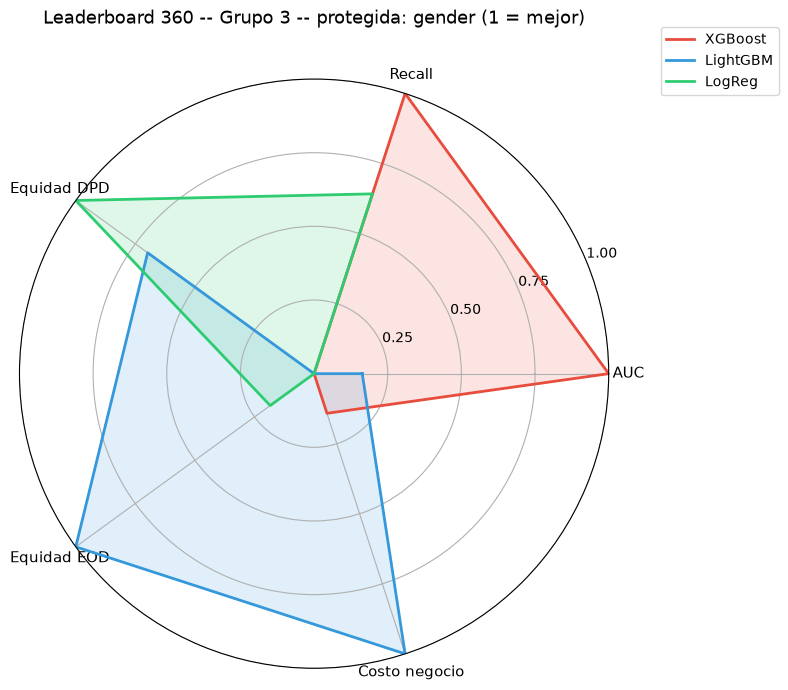

Figura guardada: leaderboard360_g03_20260918.png

=== Quién gana cada eje ===
  Mejor AUC                  -> XGBoost    = 0.8369
  Mejor Recall               -> XGBoost    = 0.7861
  Mejor DPD                  -> LogReg     = 0.004
  Mejor EOD                  -> LightGBM   = 0.0642
  Mejor Costo_negocio_USD    -> LightGBM   = 33812.75

=== Justificación de la selección ===
Filtro de equidad: EOD <= 0.2 (las que no pasan quedan con Score_final = -1)
  XGBoost    EOD=0.0995 -> PASA          | Recall=0.7861 | Costo=$34,455.35
  LightGBM   EOD=0.0642 -> PASA          | Recall=0.7487 | Costo=$33,812.75
  LogReg     EOD=0.0930 -> PASA          | Recall=0.7727 | Costo=$34,561.25

GANADORA: XGBoost


In [50]:
# ========================================
# LEADERBOARD 360 -- radar normalizado (1 = mejor en cada eje)
# ========================================
import matplotlib.pyplot as plt

def normalizar(serie, invertir=False):
    v = serie.astype(float)
    lo, hi = v.min(), v.max()
    if hi == lo:
        return pd.Series([0.5] * len(v), index=v.index)
    norm = (v - lo) / (hi - lo)
    return 1.0 - norm if invertir else norm

sc = pd.DataFrame(metricas_finales)

radar_data = pd.DataFrame({
    "Arquitectura": sc["Arquitectura"],
    "AUC": normalizar(sc["AUC"]),
    "Recall": normalizar(sc["Recall"]),
    "Equidad DPD": normalizar(sc["DPD"].abs(), invertir=True),
    "Equidad EOD": normalizar(sc["EOD"].abs(), invertir=True),
    "Costo negocio": normalizar(sc["Costo_negocio_USD"], invertir=True),
})

ejes = ["AUC", "Recall", "Equidad DPD", "Equidad EOD", "Costo negocio"]
N = len(ejes)
angulos = [n / float(N) * 2 * np.pi for n in range(N)]
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colores = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]
for i, row in radar_data.iterrows():
    valores = row[ejes].tolist() + [row[ejes[0]]]
    ax.plot(angulos, valores, linewidth=2, label=row["Arquitectura"], color=colores[i % len(colores)])
    ax.fill(angulos, valores, alpha=0.15, color=colores[i % len(colores)])
ax.set_xticks(angulos[:-1])
ax.set_xticklabels(ejes, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.legend(loc="upper right", bbox_to_anchor=(1.30, 1.10), fontsize=10)
plt.title(f"Leaderboard 360 -- Grupo 3 -- protegida: {PROTECTED_VAR_RAW} (1 = mejor)", y=1.08, fontsize=13)
plt.tight_layout()
plt.savefig(f"leaderboard360_{GROUP_NUM}_{FECHA_CLASE}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: leaderboard360_{GROUP_NUM}_{FECHA_CLASE}.png")

print("\n=== Quién gana cada eje ===")
for m, menos_es_mejor in [("AUC", False), ("Recall", False), ("DPD", True), ("EOD", True), ("Costo_negocio_USD", True)]:
    col = sc[m].abs() if m in ("DPD", "EOD") else sc[m]
    idx = col.idxmin() if menos_es_mejor else col.idxmax()
    print(f"  Mejor {m:20s} -> {sc.loc[idx, 'Arquitectura']:10s} = {sc.loc[idx, m]}")

print("\n=== Justificación de la selección ===")
print(f"Filtro de equidad: EOD <= {EOD_MAX} (las que no pasan quedan con Score_final = -1)")
for _, f in df_leaderboard.iterrows():
    estado = "PASA" if f["Score_final"] > -1 else "DESCALIFICADA"
    print(f"  {f['Arquitectura']:10s} EOD={f['EOD']:.4f} -> {estado:13s} | Recall={f['Recall']:.4f} | Costo=${f['Costo_negocio_USD']:,.2f}")
print(f"\nGANADORA: {ganador}")


---
## SECCIÓN 6: Registro en Vertex AI Experiments

In [51]:
# ========================================
# REGISTRO EN VERTEX AI EXPERIMENTS
# ========================================
from sklearn.metrics import roc_curve

for arquitectura in arquitecturas:
    res_mit = resultados[f"{arquitectura}_mitigado"]
    res_base = resultados[f"{arquitectura}_base"]
    fila = next(f for f in metricas_finales if f["Arquitectura"] == arquitectura)

    run_name = f"u4-{GROUP_NUM}-exp-{FECHA_CLASE}-{arquitectura.lower()}"

    try:
        run_ctx = aiplatform.start_run(run_name, resume=True)
    except Exception:
        run_ctx = aiplatform.start_run(run_name)

    with run_ctx as run:
        run.log_params({"protected_var": PROTECTED_VAR_RAW, "eod_max": EOD_MAX, "group_num": GROUP_NUM})
        run.log_metrics({
            "auc": fila["AUC"], "precision": fila["Precision"], "recall": fila["Recall"],
            "dpd": fila["DPD"], "eod": fila["EOD"],
            "auc_base": fila["AUC_base (sin mitigar)"], "eod_base": fila["EOD_base (sin mitigar)"],
            "costo_negocio_usd": fila["Costo_negocio_USD"],
        })
        if fila["Costo_equidad_ratio"] is not None:
            run.log_metrics({"costo_equidad_ratio": fila["Costo_equidad_ratio"]})

        fpr, tpr, thresh = roc_curve(y_test, res_mit["modelo"].predict_proba(X_test)[:, 1])
        thresh = np.clip(thresh, 0, 1)
        aiplatform.log_classification_metrics(
            labels=["No Churn", "Churn"],
            matrix=res_mit["confusion_matrix"].tolist(),
            fpr=fpr.tolist(), tpr=tpr.tolist(), threshold=thresh.tolist(),
            display_name=f"cm_{run_name}",
        )
    print(f"Logueado a Experiments: {run_name}")


Logueado a Experiments: u4-g03-exp-20260918-xgboost


Logueado a Experiments: u4-g03-exp-20260918-lightgbm


Logueado a Experiments: u4-g03-exp-20260918-logreg


---
## SECCIÓN 7: Registro en Model Registry

Guardamos las 3 arquitecturas (versión mitigada) en Cloud Storage y las registramos en Model Registry. La ganadora queda marcada con `labels={"ganador": "true"}`, las demás se conservan como evidencia de la competencia. No se crea Endpoint -- eso es U5.

In [52]:
# ========================================
# GUARDAR Y REGISTRAR LOS 3 MODELOS -- sin deploy
# ========================================
import joblib, os
from google.cloud import storage

storage_client = storage.Client(project=PROJECT_ID)
bucket = storage_client.bucket(BUCKET_NAME)
if not bucket.exists():
    print(f"El bucket {BUCKET_NAME} no existe -- creándolo en {REGION}...")
    bucket = storage_client.create_bucket(BUCKET_NAME, location=REGION)
    print(f"Bucket creado: {BUCKET_NAME}")
else:
    print(f"Bucket ya existe: {BUCKET_NAME}")

# Verificar versiones antes de elegir el contenedor de serving (puede requerir contenedor custom)
!pip show xgboost | grep Version
!pip show lightgbm | grep Version
!pip show scikit-learn | grep Version

# OJO: revisar el contenedor prediseñado disponible para cada framework antes de correr.
# XGBoost -> us-docker.pkg.dev/vertex-ai/prediction/xgboost-cpu.<version>:latest
# sklearn (LogReg)/LightGBM -> puede requerir contenedor custom o el sklearn-cpu generico;
# verificar compatibilidad de version antes de desplegar en U5.
SERVING_CONTAINERS = {
    "XGBoost": "us-docker.pkg.dev/vertex-ai/prediction/xgboost-cpu.1-4:latest",   # <- revisar version
    "LightGBM": "us-docker.pkg.dev/vertex-ai/prediction/sklearn-cpu.1-3:latest", # <- revisar, puede requerir custom
    "LogReg": "us-docker.pkg.dev/vertex-ai/prediction/sklearn-cpu.1-3:latest",
}

modelos_uploaded = {}
for arquitectura in arquitecturas:
    modelo_arq = resultados[f"{arquitectura}_mitigado"]["modelo"]

    MODEL_DIR = f"u4_{GROUP_NUM}_mdl_{FECHA_CLASE}_{arquitectura.lower()}"
    os.makedirs(MODEL_DIR, exist_ok=True)
    joblib.dump(modelo_arq, f"{MODEL_DIR}/model.joblib")

    GCS_PREFIX = f"u4_{GROUP_NUM}_mdl_{FECHA_CLASE}_{arquitectura.lower()}"
    GCS_MODEL_PATH = f"gs://{BUCKET_NAME}/{GCS_PREFIX}"

    blob = bucket.blob(f"{GCS_PREFIX}/model.joblib")
    blob.upload_from_filename(f"{MODEL_DIR}/model.joblib")
    print(f"Modelo {arquitectura} subido a {GCS_MODEL_PATH}/model.joblib")

    es_ganador = (arquitectura == ganador)

    model_uploaded = aiplatform.Model.upload(
        display_name=f"u4_{GROUP_NUM}_mdl_{FECHA_CLASE}_{arquitectura.lower()}",
        artifact_uri=GCS_MODEL_PATH,
        serving_container_image_uri=SERVING_CONTAINERS[arquitectura],
        labels={"ganador": "true" if es_ganador else "false", "arquitectura": arquitectura.lower(), "grupo": GROUP_NUM},
    )
    modelos_uploaded[arquitectura] = model_uploaded
    print(f"Modelo {arquitectura} registrado (SIN desplegar){' -- GANADOR' if es_ganador else ''}: {model_uploaded.resource_name}")


Bucket ya existe: computacionnube20263-u4-g03-mdl-20260918
Version: 3.4.1
Version: 4.7.0
Version: 1.9.1
Modelo XGBoost subido a gs://computacionnube20263-u4-g03-mdl-20260918/modelo_churn_xgboost/model.joblib
Creating Model
Create Model backing LRO: projects/150348605007/locations/us-central1/models/5121094703378333696/operations/8169345336809095168
Model created. Resource name: projects/150348605007/locations/us-central1/models/5121094703378333696@1
To use this Model in another session:
model = aiplatform.Model('projects/150348605007/locations/us-central1/models/5121094703378333696@1')
Modelo XGBoost registrado (SIN desplegar) -- GANADOR: projects/150348605007/locations/us-central1/models/5121094703378333696
Modelo LightGBM subido a gs://computacionnube20263-u4-g03-mdl-20260918/modelo_churn_lightgbm/model.joblib
Creating Model
Create Model backing LRO: projects/150348605007/locations/us-central1/models/8508927523067789312/operations/527158981626429440
Model created. Resource name: proj

---
## SECCIÓN 8: Handoff a Unidad 5 — contrato exacto del servicio

**Esta celda es crítica.** El servicio de U5 construye el vector de features a mano, y si un solo nombre o el orden no coinciden con lo que el modelo espera, XGBoost/LightGBM **no lanzan error** cuando reciben un array posicional — simplemente predicen mal, en silencio. Todo lo que imprime esta celda se copia **literal** a `schemas.py`.

In [53]:
# ========================================
# HANDOFF A UNIDAD 5 -- copiar esta salida literal a schemas.py
# ========================================
import sklearn, xgboost, lightgbm, json as _json

ganador_slug = ganador.lower()
GCS_MODEL_PATH_GANADOR = f"gs://{BUCKET_NAME}/u4_{GROUP_NUM}_mdl_{FECHA_CLASE}_{ganador_slug}/model.joblib"
MODEL_VERSION_GANADOR = f"u4_{GROUP_NUM}_mdl_{FECHA_CLASE}_{ganador_slug}"

print("=" * 78)
print("1. FEATURE_ORDER -- orden y nombres EXACTOS que espera el modelo")
print("=" * 78)
print("FEATURE_ORDER = [")
for c in X_train.columns:
    print(f'    "{c}",')
print("]")

print("\n" + "=" * 78)
print("2. VALORES CRUDOS de cada categórica (dominio de los enums en schemas.py)")
print("=" * 78)
for c in cat_cols:
    vals = sorted(df[c].astype(str).unique().tolist())
    base = vals[0]  # drop_first=True elimina la PRIMERA categoria -> es la categoria base (todo 0)
    print(f"  {c:20s} valores={vals}")
    print(f"  {'':20s} categoría BASE (implícita, no tiene columna): {base!r}")

print("\n" + "=" * 78)
print("3. RUTAS Y VERSIÓN del modelo ganador (para el deploy de Cloud Run)")
print("=" * 78)
print(f"  Arquitectura ganadora : {ganador}")
print(f"  MODEL_GCS_URI         : {GCS_MODEL_PATH_GANADOR}")
print(f"  MODEL_VERSION         : {MODEL_VERSION_GANADOR}")
print(f"  BUCKET_NAME           : {BUCKET_NAME}")

print("\n" + "=" * 78)
print("4. VERSIONES DE LIBRERÍAS -- fijar EXACTAS en requirements.txt del servicio")
print("=" * 78)
print(f"  scikit-learn=={sklearn.__version__}")
print(f"  xgboost=={xgboost.__version__}")
print(f"  lightgbm=={lightgbm.__version__}")
print("  (si joblib.load falla en Cloud Run, casi siempre es desajuste de estas versiones)")

print("\n" + "=" * 78)
print("5. SMOKE TEST -- vector de referencia para validar schemas.py")
print("=" * 78)
fila_ref = X_test.iloc[[0]]
proba_ref = float(resultados[f"{ganador}_mitigado"]["modelo"].predict_proba(fila_ref)[0][1])
print("  Input (features ya codificadas):")
print(_json.dumps({k: float(v) for k, v in fila_ref.iloc[0].to_dict().items()}, indent=4))
print(f"  predict_proba[1] esperado = {proba_ref:.6f}")
print("  -> to_feature_vector() de schemas.py DEBE producir exactamente este vector,")
print("     y el servicio DEBE devolver este mismo score para ese cliente.")

# Guardar el handoff a disco para no depender de copiar de la consola
handoff = {
    "grupo": GROUP_NUM,
    "fecha": FECHA_CLASE,
    "arquitectura_ganadora": ganador,
    "feature_order": list(X_train.columns),
    "categorias_crudas": {c: sorted(df[c].astype(str).unique().tolist()) for c in cat_cols},
    "categoria_base_drop_first": {c: sorted(df[c].astype(str).unique().tolist())[0] for c in cat_cols},
    "model_gcs_uri": GCS_MODEL_PATH_GANADOR,
    "model_version": MODEL_VERSION_GANADOR,
    "bucket": BUCKET_NAME,
    "versiones": {"scikit-learn": sklearn.__version__, "xgboost": xgboost.__version__, "lightgbm": lightgbm.__version__},
    "smoke_test": {
        "features": {k: float(v) for k, v in fila_ref.iloc[0].to_dict().items()},
        "proba_esperada": proba_ref,
    },
    "scorecard": metricas_finales,
}
HANDOFF_FILENAME = f"handoff_u5_{GROUP_NUM}_{FECHA_CLASE}.json"
LEADERBOARD_FILENAME = f"leaderboard360_{GROUP_NUM}_{FECHA_CLASE}.png"
ARTIFACT_PREFIX = f"u4_{GROUP_NUM}_artifacts_{FECHA_CLASE}"
handoff["artifact_gcs_uris"] = {
    "handoff": f"gs://{BUCKET_NAME}/{ARTIFACT_PREFIX}/{HANDOFF_FILENAME}",
    "leaderboard360": f"gs://{BUCKET_NAME}/{ARTIFACT_PREFIX}/{LEADERBOARD_FILENAME}",
}

with open(HANDOFF_FILENAME, "w") as f:
    _json.dump(handoff, f, indent=2, default=str)

for artifact_filename in (HANDOFF_FILENAME, LEADERBOARD_FILENAME):
    if not os.path.exists(artifact_filename):
        raise FileNotFoundError(f"No se encontró el artefacto esperado: {artifact_filename}")
    artifact_blob = bucket.blob(f"{ARTIFACT_PREFIX}/{artifact_filename}")
    artifact_blob.upload_from_filename(artifact_filename)
    print(f"Artefacto subido: gs://{BUCKET_NAME}/{ARTIFACT_PREFIX}/{artifact_filename}")

print(f"\nHandoff guardado en {HANDOFF_FILENAME} y respaldado en Cloud Storage")


1. FEATURE_ORDER -- orden y nombres EXACTOS que espera el modelo
FEATURE_ORDER = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "gender_Male",
    "Partner_True",
    "Dependents_True",
    "Contract_One_year",
    "Contract_Two_year",
    "PaymentMethod_Credit_card__automatic_",
    "PaymentMethod_Electronic_check",
    "PaymentMethod_Mailed_check",
    "InternetService_Fiber_optic",
    "InternetService_No",
    "OnlineSecurity_No_internet_service",
    "OnlineSecurity_Yes",
    "TechSupport_No_internet_service",
    "TechSupport_Yes",
    "PaperlessBilling_True",
]

2. VALORES CRUDOS de cada categórica (dominio de los enums en schemas.py)
  gender               valores=['Female', 'Male']
                       categoría BASE (implícita, no tiene columna): 'Female'
  Partner              valores=['False', 'True']
                       categoría BASE (implícita, no tiene columna): 'False'
  Dependents           valores=['False', 'True']
                       categorí

---
## Cierre

**Antes de apagar la instancia de Workbench, descargar:**
1. `handoff_u5_g03_20260918.json` — contrato exacto para `schemas.py` de U5 (Sección 8)
2. `leaderboard360_g03_20260918.png` — figura del leaderboard 360 (Sección 5.1)
3. Este notebook ya ejecutado, con todos los outputs visibles

**Se conservan:** el bucket, el Model Registry y los demás artefactos. Solo se apaga y borra la **instancia** de Workbench.

**Siguiente paso:** Unidad 5 — convertir el modelo ganador en servicio FastAPI desplegado en Cloud Run.
